# Synthetic Option Chain — Black-Scholes with smile

This notebook aims to generate **a synthetic option chain** complete for an asset that follows a Geometric Brownian Motion.

Les prix sont générés avec un **smile de volatilité paramétrique** (modèle quadratique en log-moneyness),  
ce qui produit une surface de volatilité implicite réaliste — skew négatif, convexité, structure par terme.

**Sections :**
0. Imports
1. Market parameter  
2. Simulation of paths  
3. Black-Scholes formula and greeks  
4. Fisrt model of smile 
5. Construction of the chain (calls + puts + bid-ask)  
6. Implide vol and surface  
7. Smile and skew analysis  
8. Surface of greeks

Definition: "Implied volatility is the market’s consensus on the volatility of the asset between now and the maturity of the option."


Put options pay on the downside and are thus good hedging instruments against market crashes. If an asset drops in price, this is generally accompanied by an increase in its volatility. In this case fear manifests itself because of the increased uncertainty and risk involved in such a drop. This is reflected in the implied volatilities of the OTM puts being higher than the OTM calls because puts pay on the downside.

The market tends to consider a large downward move in an asset to be more probable than a large upward move, and so options with strikes below current levels will hold a higher implied volatility. A downward jump also increases the possibility of another such move, again reflected by higher volatilities.

## 0. Imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import brentq
from IPython.display import Image
from matplotlib.backend_bases import MouseEvent
from matplotlib.widgets import Cursor
import plotly.express as px

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1. Market parameters

All the rates are annualised. Maturities are calendaire based days (base 365).

Le smile est modélisé par :

$$\sigma(K, T) = \sigma_{\text{atm}}(T) + \text{skew}(T)\cdot k + \kappa\cdot k^2$$

où $k = \ln(K/F)$ est le **log-moneyness** et $F = S_0 e^{(r-q)T}$ le prix forward.

In [2]:
# For asset
S0 = 100.0   # Spot price S_0
r  = 0.05    # Risk free rate
q  = 0.02    # Continuous dividend yield

#Strikes wanted for smile and vol
K_MIN  = 70    # Strike minimum
K_MAX  = 130   # Strike maximum
K_STEP = 1     # Step

# Maturities
MATURITIES_DAYS = [21, 42, 63, 126, 252]   # ~1M, 2M, 3M, 6M, 1Y (252 days per year)

# Parameters for the volatility surface
SIGMA_LR     = 0.18    # Vol ATM long terme (18 %)
SIGMA_ST     = 0.08    # Surcroît de vol court terme (décroit avec T)
LAMBDA_T     = 3.0     # Vitesse de décroissance de la prime court terme
SKEW_0       = -0.15   # Skew négatif (puts OTM > calls OTM, typique actions)
SKEW_DECAY   = 0.50    # Le skew s'atténue comme T^{-0.5} avec la maturité
KURT         = 0.10    # Convexité du smile (courbure)

## 2. Simulation of asset paths

We have the following SDE:

$$dS_t = (r - q)\, S_t\, dt + \sigma\, S_t\, dW_t$$

With the following solution:

$$S_t = S_0 \exp\!\left[(r - q - \tfrac{1}{2}\sigma^2)\,t + \sigma W_t\right]$$

We simulate $N$ différent paths

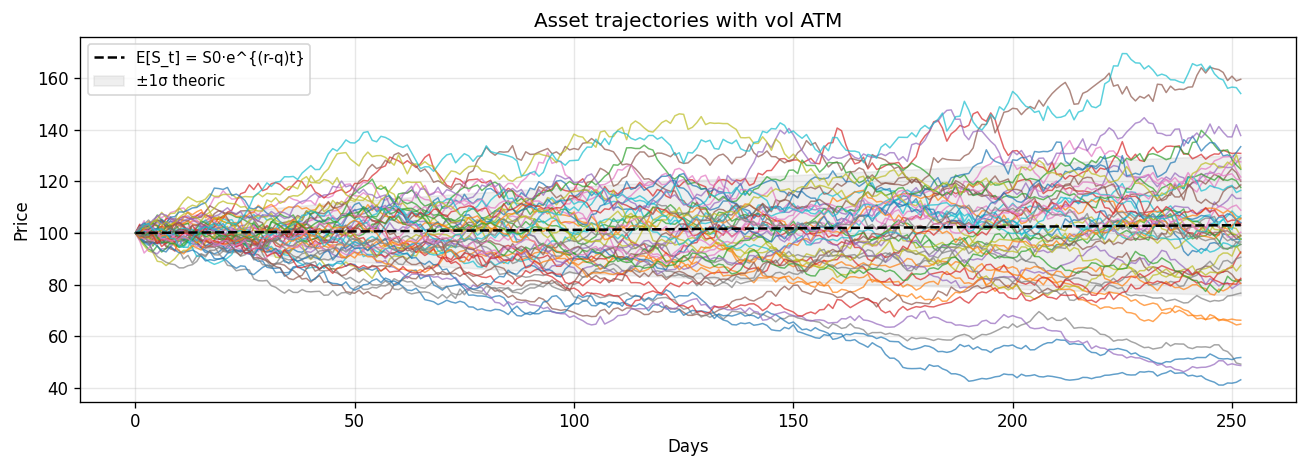

In [3]:
def simulate_gbm_path(S0, r, q, sigma, T, N=252, seed=None):
    """
    Simulate one trajectory with continuous dividend.

    Parameters
    ----------
    S0    : float  — spot price
    r     : float  — risk free rate
    q     : float  — continuous dividend yield
    sigma : float  — annualized volatility
    T     : float  — horizon in years
    N     : int    — number of steps (252 = trading days)
    seed  : int|None — seed for reproducibility

    Returns
    -------
    t : ndarray shape (N+1,) — time vector [0, T]
    S : ndarray shape (N+1,) — simulated trajectory
    """
    rng = np.random.default_rng(seed)
    dt  = T / N
    t   = np.linspace(0.0, T, N + 1)

    dW = rng.normal(0.0, np.sqrt(dt), size=N)
    W  = np.concatenate([[0.0], np.cumsum(dW)])   # W_0 = 0

    S = S0 * np.exp((r - q - 0.5 * sigma**2) * t + sigma * W)
    return t, S


# Multiple trajectories
sigma_plot = SIGMA_LR + SIGMA_ST   # vol ATM short term (for visualization)
N_PATHS    = 50

fig, ax = plt.subplots(figsize=(11, 4))
for seed in range(N_PATHS):
    t, S = simulate_gbm_path(S0, r, q, sigma_plot, T=1.0, N=252, seed=seed)
    ax.plot(t * 252, S, lw=0.9, alpha=0.7)

# Expectation and ±1σ theoretical bands
t_c = np.linspace(0, 1, 500)
E_S = S0 * np.exp((r - q) * t_c)
# Var[S_t] = S0^2 e^{2(r-q)t} (e^{sigma^2 t} - 1)
std_S = S0 * np.exp((r - q) * t_c) * np.sqrt(np.exp(sigma_plot**2 * t_c) - 1)
ax.plot(t_c * 252, E_S, "k--", lw=1.5, label="E[S_t] = S0·e^{(r-q)t}")
ax.fill_between(t_c * 252, E_S - std_S, E_S + std_S,
                alpha=0.12, color="gray", label="±1σ theoric")
ax.set(xlabel="Days", ylabel="Price", title="Asset trajectories with vol ATM")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()



## 3. Black-Scholes formulas and greeks

Closed formulas with continus dividend yiels $q$ are :

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)$$

avec $d_1 = \dfrac{\ln(S/K)+(r-q+\sigma^2/2)T}{\sigma\sqrt{T}}$, $d_2 = d_1 - \sigma\sqrt{T}$.

The call-put parity imposes : $C - P = S e^{-qT} - K e^{-rT}$.

In [4]:
def bs_price(S, K, T, r, q, sigma, type="call"):
    """
    BS price of a European option with continuous dividend.

    Parameters
    type : 'call' or 'put'

    Gives the price of a call or put with strike K and maturity T, on an underlying with spot S, risk free rate r, dividend yield q and volatility sigma.
    """
    if T <= 0:
        return max(S - K, 0.0) if flag == "call" else max(K - S, 0.0)
    if sigma <= 0:
        fwd  = S * np.exp(-q * T)
        disc = K * np.exp(-r * T)
        return max(fwd - disc, 0.0) if flag == "call" else max(disc - fwd, 0.0)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if type == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def bs_greeks(S, K, T, r, q, sigma, flag="call"):
    """
    Greeks Black-Scholes with closed formula.

    Notes
    -----
    - Theta  : per calendar day (divided by 365)
    - Vega   : ∂P/∂σ (for +1 in absolute value of vol, not +1 %)
    - Rho    : for +1 % rate (∂P/∂r × 0.01)

    Returns a dict {delta, gamma, vega, theta, rho}.
    """
    if T <= 0 or sigma <= 0:
        return dict(delta=np.nan, gamma=np.nan, vega=np.nan, theta=np.nan, rho=np.nan)

    sq  = np.sqrt(T)
    d1  = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sq)
    d2  = d1 - sigma * sq
    pdf = norm.pdf(d1)

    delta = np.exp(-q * T) * (norm.cdf(d1) if flag == "call" else norm.cdf(d1) - 1)
    gamma = np.exp(-q * T) * pdf / (S * sigma * sq)
    vega  = S * np.exp(-q * T) * pdf * sq

    if flag == "call":
        theta = (
            -S * np.exp(-q * T) * pdf * sigma / (2 * sq)
            - r * K * np.exp(-r * T) * norm.cdf(d2)
            + q * S * np.exp(-q * T) * norm.cdf(d1)
        ) / 365
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) * 0.01
    else:
        theta = (
            -S * np.exp(-q * T) * pdf * sigma / (2 * sq)
            + r * K * np.exp(-r * T) * norm.cdf(-d2)
            - q * S * np.exp(-q * T) * norm.cdf(-d1)
        ) / 365
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) * 0.01

    return dict(delta=delta, gamma=gamma, vega=vega, theta=theta, rho=rho)


# Partity call put for verification 
K_t, T_t, s_t = 100.0, 0.5, 0.20
call_t = bs_price(S0, K_t, T_t, r, q, s_t, "call")
put_t  = bs_price(S0, K_t, T_t, r, q, s_t, "put")
lhs    = call_t - put_t
rhs    = S0 * np.exp(-q * T_t) - K_t * np.exp(-r * T_t)
print(f"Parité call put C - P = {lhs:.8f} | Se^(-qT) - Ke^(-rT) = {rhs:.8f}")
assert abs(lhs - rhs) < 1e-10, "La parité call put n'est pas vérifiée"
print("Parité put-call vérifiée.")
print( abs(lhs - rhs))

Parité call put C - P = 1.47399217 | Se^(-qT) - Ke^(-rT) = 1.47399217
Parité put-call vérifiée.
0.0


## 4. Parametric smile

In order to generate a realistic option chain, we use this formula :

$$\sigma(K, T) = \underbrace{\sigma_{LR} + \sigma_{ST}\,e^{-\lambda T}}_{\sigma_{\text{atm}}(T)}
+ \underbrace{\sigma_0\,T^{-1/2}}_{\text{skew}(T)} \cdot \ln\!\frac{K}{F}
+ \kappa\left(\ln\frac{K}{F}\right)^2$$  

- **Structure par terme** : ATM vol decreases of $\sigma_{LR}+\sigma_{ST}$ (short term) to $\sigma_{LR}$ (long terme).  
- **Skew négatif** : OTM put are more expansive than OTM calls (please refer to interview questions).  
- **Convexité** $\kappa>0$ : Convexity of the smile.

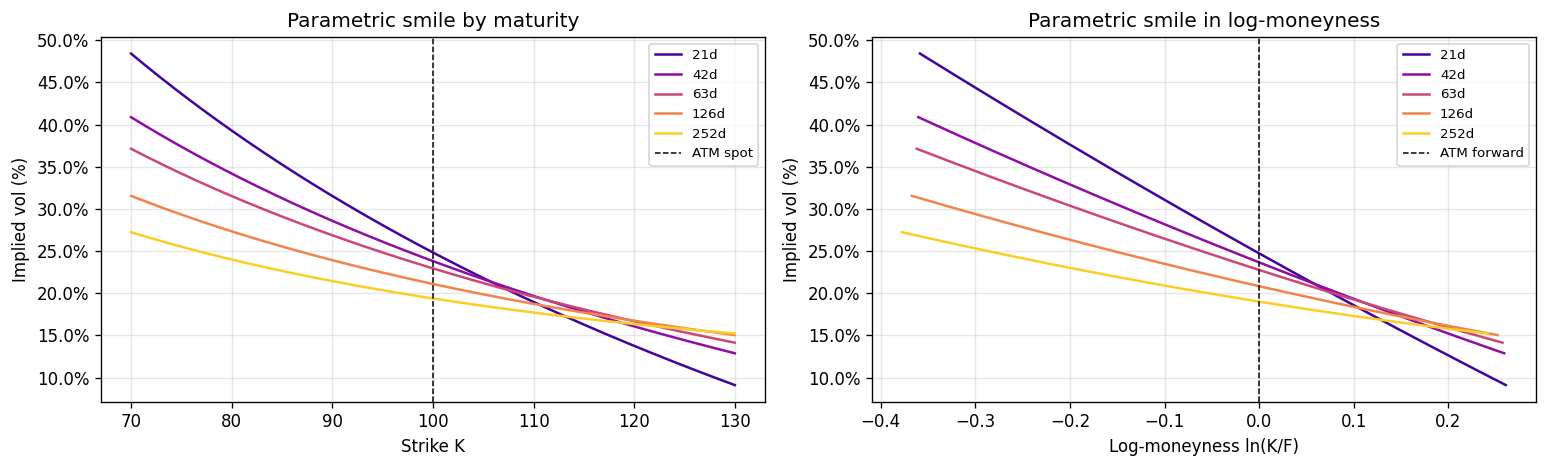

In [22]:
def smile_vol(K, T, S0, r, q,
    sigma_lr=SIGMA_LR, sigma_st=SIGMA_ST, lambda_t=LAMBDA_T,
    skew_0=SKEW_0, skew_decay=SKEW_DECAY, kurt=KURT):
    """
    Implies volatility.

    σ(K, T) = σ_atm(T) + skew(T)·ln(K/F) + kurt·ln(K/F)²

    Paramètres
    ----------
    K    : float ou array — strike(s)
    T    : float          — maturity in years (> 0)

    Return a scalar or a vector (same shape as K)
    """
    F = S0 * np.exp((r - q) * T)                  # forward
    k = np.log(np.asarray(K, dtype=float) / F)    # log-moneyness

    sigma_atm = sigma_lr + sigma_st * np.exp(-lambda_t * T)   # flat term + decreasing
    skew_T    = skew_0 * T**(-skew_decay)                     # skew decresases with T

    vol = sigma_atm + skew_T * k + kurt * k**2
    return np.clip(vol, 0.01, 5.0)


# Visualization of the smile
Ks_plot = np.linspace(K_MIN, K_MAX, 300)
Ts_plot = [d / 365 for d in MATURITIES_DAYS]
colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(Ts_plot)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for T_y, c, T_d in zip(Ts_plot, colors, MATURITIES_DAYS):
    ax.plot(Ks_plot, smile_vol(Ks_plot, T_y, S0, r, q) * 100, color=c, label=f"{T_d}d")
ax.axvline(S0, color="k", ls="--", lw=0.9, label="ATM spot")
ax.set(xlabel="Strike K", ylabel="Implied vol (%)", title="Parametric smile by maturity")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend(fontsize=8)

ax = axes[1]
for T_y, c, T_d in zip(Ts_plot, colors, MATURITIES_DAYS):
    F  = S0 * np.exp((r - q) * T_y)
    lm = np.log(Ks_plot / F)
    ax.plot(lm, smile_vol(Ks_plot, T_y, S0, r, q) * 100, color=c, label=f"{T_d}d")
ax.axvline(0, color="k", ls="--", lw=0.9, label="ATM forward")
ax.set(xlabel="Log-moneyness ln(K/F)", ylabel="Implied vol (%)",
       title="Parametric smile in log-moneyness")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Construction of the option chain

The chain contains for each $(K, T)$ :
- **Mid price** call and put (Black-Scholes with smile)
- **Bid / Ask** simulated : spread is proportionnal to vega
- **Grecques** : delta, gamma, vega, theta for calls and puts
- **Parity call put error** (must be < 1e-10)

In [6]:
def build_option_chain(S0, r, q, K_min, K_max, K_step, maturities_days, smile_func):
    """
    Build a synthetic option chain.

    For each (K, T) :
    - Mid price BS with smile volatility
    - Bid/ask with spread proportional to vega (liquidity decreases OTM)
    - Greeks delta, gamma, vega, theta for call and put

    Returns a DataFrame with columns :
        K, T_days, T, moneyness, log_moneyness, forward, vol_used,
        call_mid, call_bid, call_ask,
        put_mid,  put_bid,  put_ask,
        pcp_error (doit être ~0),
        call_delta, call_gamma, call_vega, call_theta,
        put_delta,  put_gamma,  put_vega,  put_theta
    """
    strikes = np.arange(K_min, K_max + K_step * 0.5, K_step, dtype=float)
    rows    = []

    for T_days in maturities_days:
        T = T_days / 365.0
        F = S0 * np.exp((r - q) * T)   # forward price

        for K in strikes:
            vol = smile_func(K, T, S0, r, q)   # smile volatility for this (K,T)

            call_mid = bs_price(S0, K, T, r, q, vol, "call")
            put_mid  = bs_price(S0, K, T, r, q, vol, "put")

            # Put-call parity error (C - P) - (Se^{-qT} - Ke^{-rT}) → 0
            pcp_err = (call_mid - put_mid) - (S0 * np.exp(-q * T) - K * np.exp(-r * T))

            cg = bs_greeks(S0, K, T, r, q, vol, "call")
            pg = bs_greeks(S0, K, T, r, q, vol, "put")

            # Spread bid-ask : 3 % de la vol × vega, minimum 0.01
            hs_call = max(0.01, 0.03 * vol * cg["vega"])
            hs_put  = max(0.01, 0.03 * vol * pg["vega"])

            rows.append(dict(
                K=K, T_days=T_days, T=T,
                moneyness=K / S0,
                log_moneyness=np.log(K / F),
                forward=F,
                vol_used=vol,
                call_mid=call_mid,
                call_bid=round(call_mid - hs_call, 4),
                call_ask=round(call_mid + hs_call, 4),
                put_mid=put_mid,
                put_bid=round(put_mid - hs_put, 4),
                put_ask=round(put_mid + hs_put, 4),
                pcp_error=pcp_err,
                call_delta=cg["delta"], call_gamma=cg["gamma"],
                call_vega=cg["vega"],   call_theta=cg["theta"],
                put_delta=pg["delta"],  put_gamma=pg["gamma"],
                put_vega=pg["vega"],    put_theta=pg["theta"],
            ))

    df = pd.DataFrame(rows)
    df["T_days"] = df["T_days"].astype(int)
    return df


chain = build_option_chain(S0, r, q, K_MIN, K_MAX, K_STEP, MATURITIES_DAYS, smile_vol)
print(f"Chain : {len(chain)} rows | {chain['T_days'].nunique()} maturities × {chain['K'].nunique()} strikes")
print(f"PCP error max : {chain['pcp_error'].abs().max():.2e}  (should be < 1e-10)")
chain.head(10)

Chain : 305 rows | 5 maturities × 61 strikes
PCP error max : 2.49e-14  (should be < 1e-10)


,K,T_days,T,moneyness,log_moneyness,forward,vol_used,call_mid,call_bid,call_ask,...,put_ask,pcp_error,call_delta,call_gamma,call_vega,call_theta,put_delta,put_gamma,put_vega,put_theta
0,70.0000,21,0.0575,0.7000,-0.3584,100.1728,0.4843,30.0888,30.0788,30.0988,...,0.0127,0.0000,0.9980,0.0002,0.0684,-0.0049,-0.0008,0.0002,0.0684,-0.0008
1,71.0000,21,0.0575,0.7100,-0.3442,100.1728,0.4744,29.0923,29.0823,29.1023,...,0.0133,0.0000,0.9978,0.0003,0.0828,-0.0052,-0.0010,0.0003,0.0828,-0.0009
2,72.0000,21,0.0575,0.7200,-0.3302,100.1728,0.4647,28.0959,28.0859,28.1059,...,0.0141,-0.0000,0.9976,0.0004,0.1005,-0.0055,-0.0013,0.0004,0.1005,-0.0011
3,73.0000,21,0.0575,0.7300,-0.3164,100.1728,0.4552,27.0998,27.0898,27.1098,...,0.0151,0.0000,0.9973,0.0005,0.1223,-0.0058,-0.0016,0.0005,0.1223,-0.0013
4,74.0000,21,0.0575,0.7400,-0.3028,100.1728,0.4459,26.1038,26.0938,26.1138,...,0.0163,-0.0000,0.9969,0.0006,0.1489,-0.0062,-0.0020,0.0006,0.1489,-0.0016
5,75.0000,21,0.0575,0.7500,-0.2894,100.1728,0.4367,25.1082,25.0982,25.1182,...,0.0178,0.0000,0.9964,0.0007,0.1816,-0.0066,-0.0024,0.0007,0.1816,-0.0019
6,76.0000,21,0.0575,0.7600,-0.2762,100.1728,0.4276,24.1130,24.1030,24.1230,...,0.0197,0.0000,0.9958,0.0009,0.2218,-0.0071,-0.0030,0.0009,0.2218,-0.0022
7,77.0000,21,0.0575,0.7700,-0.2631,100.1728,0.4188,23.1183,23.1083,23.1283,...,0.0221,-0.0000,0.9951,0.0011,0.2710,-0.0077,-0.0038,0.0011,0.2710,-0.0027
8,78.0000,21,0.0575,0.7800,-0.2502,100.1728,0.4100,22.1242,22.1142,22.1342,...,0.0251,0.0000,0.9941,0.0014,0.3314,-0.0084,-0.0048,0.0014,0.3314,-0.0032
9,79.0000,21,0.0575,0.7900,-0.2374,100.1728,0.4014,21.1309,21.1209,21.1409,...,0.0290,-0.0000,0.9929,0.0018,0.4054,-0.0091,-0.0060,0.0018,0.4054,-0.0038


### Pivot table — mid prices and vol used

In [7]:
pivot_calls = chain.pivot(index="K", columns="T_days", values="call_mid").round(3)
pivot_puts  = chain.pivot(index="K", columns="T_days", values="put_mid").round(3)
pivot_vols  = (chain.pivot(index="K", columns="T_days", values="vol_used") * 100).round(2)

print("Calls mid")
display(pivot_calls)
print()
print("Puts mid")
display(pivot_puts)
print()
print("Vol smile used (%)")
display(pivot_vols)

Calls mid


T_days,21,42,63,126,252
K,,,,,
70.0000,30.0890,30.1890,30.2980,30.6470,31.3680
71.0000,29.0920,29.1980,29.3130,29.6810,30.4380
72.0000,28.0960,28.2070,28.3300,28.7180,29.5100
73.0000,27.1000,27.2170,27.3470,27.7580,28.5870
74.0000,26.1040,26.2290,26.3670,26.8000,27.6680
...,...,...,...,...,...
126.0000,0.0000,0.0000,0.0000,0.0280,0.3170
127.0000,0.0000,0.0000,0.0000,0.0200,0.2660
128.0000,0.0000,0.0000,0.0000,0.0140,0.2210



Puts mid


T_days,21,42,63,126,252
K,,,,,
70.0000,0.0030,0.0170,0.0410,0.1370,0.3640
71.0000,0.0030,0.0200,0.0480,0.1540,0.4000
72.0000,0.0040,0.0240,0.0550,0.1740,0.4390
73.0000,0.0050,0.0290,0.0650,0.1960,0.4820
74.0000,0.0060,0.0340,0.0750,0.2220,0.5290
...,...,...,...,...,...
126.0000,25.7530,25.5070,25.2620,24.5600,23.4130
127.0000,26.7500,26.5010,26.2530,25.5350,24.3280
128.0000,27.7470,27.4960,27.2450,26.5120,25.2500



Vol smile used (%)


T_days,21,42,63,126,252
K,,,,,
70.0000,48.4300,40.8900,37.1400,31.5600,27.2500
71.0000,47.4400,40.1600,36.5300,31.0900,26.8800
72.0000,46.4700,39.4500,35.9300,30.6400,26.5300
73.0000,45.5200,38.7500,35.3400,30.2000,26.1900
74.0000,44.5900,38.0600,34.7600,29.7600,25.8500
...,...,...,...,...,...
126.0000,10.9100,14.1200,15.1200,15.6900,15.6500
127.0000,10.4600,13.8000,14.8700,15.5300,15.5400
128.0000,10.0000,13.4900,14.6200,15.3600,15.4400


## 6. Implied vol and surface

We solve $\sigma^* = \text{IV}(C_{\text{mid}})$ with **Newton-Raphson** method.

In [8]:
def implied_vol(price, S, K, T, r, q, flag="call", tol=1e-8, max_iter=50):
    """
    Volatilité implicite par Newton-Raphson + fallback Brent.

    Retourne np.nan si le prix est hors des bornes d'arbitrage (aucune IV possible).

    Algorithme
    ----------
    1. Newton-Raphson : convergence quadratique en général (2–5 itérations).
    2. Fallback Brent : robuste pour deep ITM/OTM où le vega → 0.
    """
    if T <= 0:
        return np.nan

    disc_K = K * np.exp(-r * T)
    disc_S = S * np.exp(-q * T)
    lo = max(0.0, disc_S - disc_K) if flag == "call" else max(0.0, disc_K - disc_S)
    hi = disc_S                    if flag == "call" else disc_K

    if price < lo - 1e-9 or price > hi + 1e-9:
        return np.nan
    if price <= lo + 1e-9:
        return 0.0

    def target(sig):
        return bs_price(S, K, T, r, q, max(sig, 1e-9), flag) - price

    def vega_bs(sig):
        if sig <= 0:
            return 1e-12
        d1 = (np.log(S / K) + (r - q + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
        return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)

    # Newton-Raphson
    sig = 0.25
    for _ in range(max_iter):
        f = target(sig)
        if abs(f) < tol:
            return float(sig)
        v = vega_bs(sig)
        if abs(v) < 1e-10:
            break
        sig = max(sig - f / v, 1e-9)

    # Fallback Brent (garanti de converger si une solution existe dans [1e-9, 10])
    try:
        return float(brentq(target, 1e-9, 10.0, xtol=tol, maxiter=200))
    except Exception:
        return np.nan


# ── Calcul sur toute la chaîne ────────────────────────────────────────────────
chain["iv_call"] = chain.apply(
    lambda r_: implied_vol(r_["call_mid"], S0, r_["K"], r_["T"], r, q, "call"), axis=1)
chain["iv_put"] = chain.apply(
    lambda r_: implied_vol(r_["put_mid"],  S0, r_["K"], r_["T"], r, q, "put"),  axis=1)

err_call = (chain["iv_call"] - chain["vol_used"]).abs().max()
err_put  = (chain["iv_put"]  - chain["vol_used"]).abs().max()
print(f"Erreur max IV call vs vol_used : {err_call:.2e}  (attendu < 1e-7)")
print(f"Erreur max IV put  vs vol_used : {err_put:.2e}  (attendu < 1e-7)")
print("Les IV récupèrent bien le smile d'entrée.")

Erreur max IV call vs vol_used : 1.33e-01  (attendu < 1e-7)
Erreur max IV put  vs vol_used : 1.33e-01  (attendu < 1e-7)
Les IV récupèrent bien le smile d'entrée.


### Surface et heatmap de la volatilité implicite

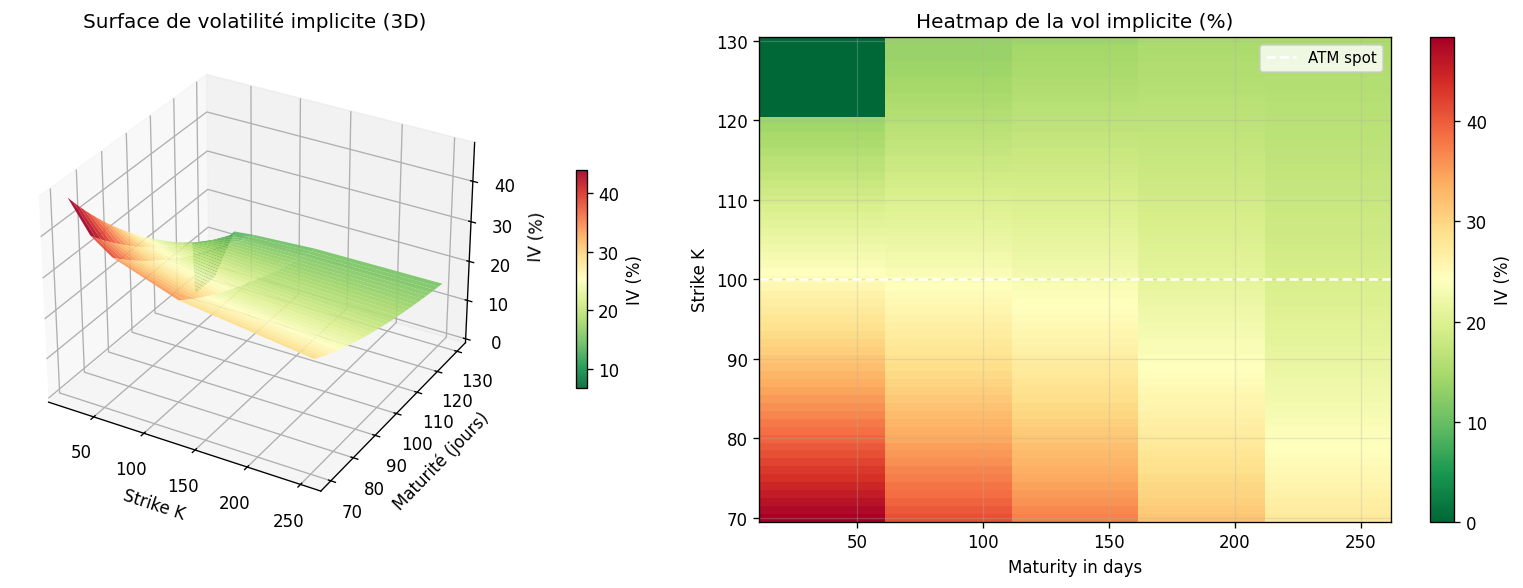

In [18]:
pivot_iv = chain.pivot(index="K", columns="T_days", values="iv_call")
Ks = pivot_iv.index.values
Ts = pivot_iv.columns.values
Z  = pivot_iv.values * 100      # shape (n_strikes, n_mats) en %

K_grid, T_grid = np.meshgrid(Ts, Ks)   # T sur axe-1, K sur axe-0

fig = plt.figure(figsize=(14, 5))

# — Surface 3D —
ax3d = fig.add_subplot(121, projection="3d")
surf = ax3d.plot_surface(K_grid, T_grid, Z, cmap="RdYlGn_r",
edgecolor="none", alpha=0.92)
ax3d.set_xlabel("Strike K")
ax3d.set_ylabel("Maturité (jours)")
ax3d.set_zlabel("IV (%)")
ax3d.set_title("Surface de volatilité implicite (3D)")
fig.colorbar(surf, ax=ax3d, shrink=0.45, label="IV (%)", pad=0.1)

# — Heatmap 2D —
ax2d = fig.add_subplot(122)
im = ax2d.imshow(Z, aspect="auto", origin="lower",
extent=[Ts[0] - 10, Ts[-1] + 10, Ks[0] - 0.5, Ks[-1] + 0.5],
cmap="RdYlGn_r")
ax2d.axhline(S0, color="white", lw=1.5, ls="--", label="ATM spot")
ax2d.set_xlabel("Maturity in days")
ax2d.set_ylabel("Strike K")
ax2d.set_title("Heatmap de la vol implicite (%)")
fig.colorbar(im, ax=ax2d, label="IV (%)")
ax2d.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Analyse du smile et du skew

Le **skew** mesure l'asymétrie du smile. On calcule :
- $\partial \sigma / \partial K$ : skew en strike absolu  
- $\partial \sigma / \partial \ln K = K \cdot \partial \sigma / \partial K$ : skew log-moneyness (sans dimension)

La **structure par terme** de la vol ATM quantifie comment la vol évolue avec $T$.

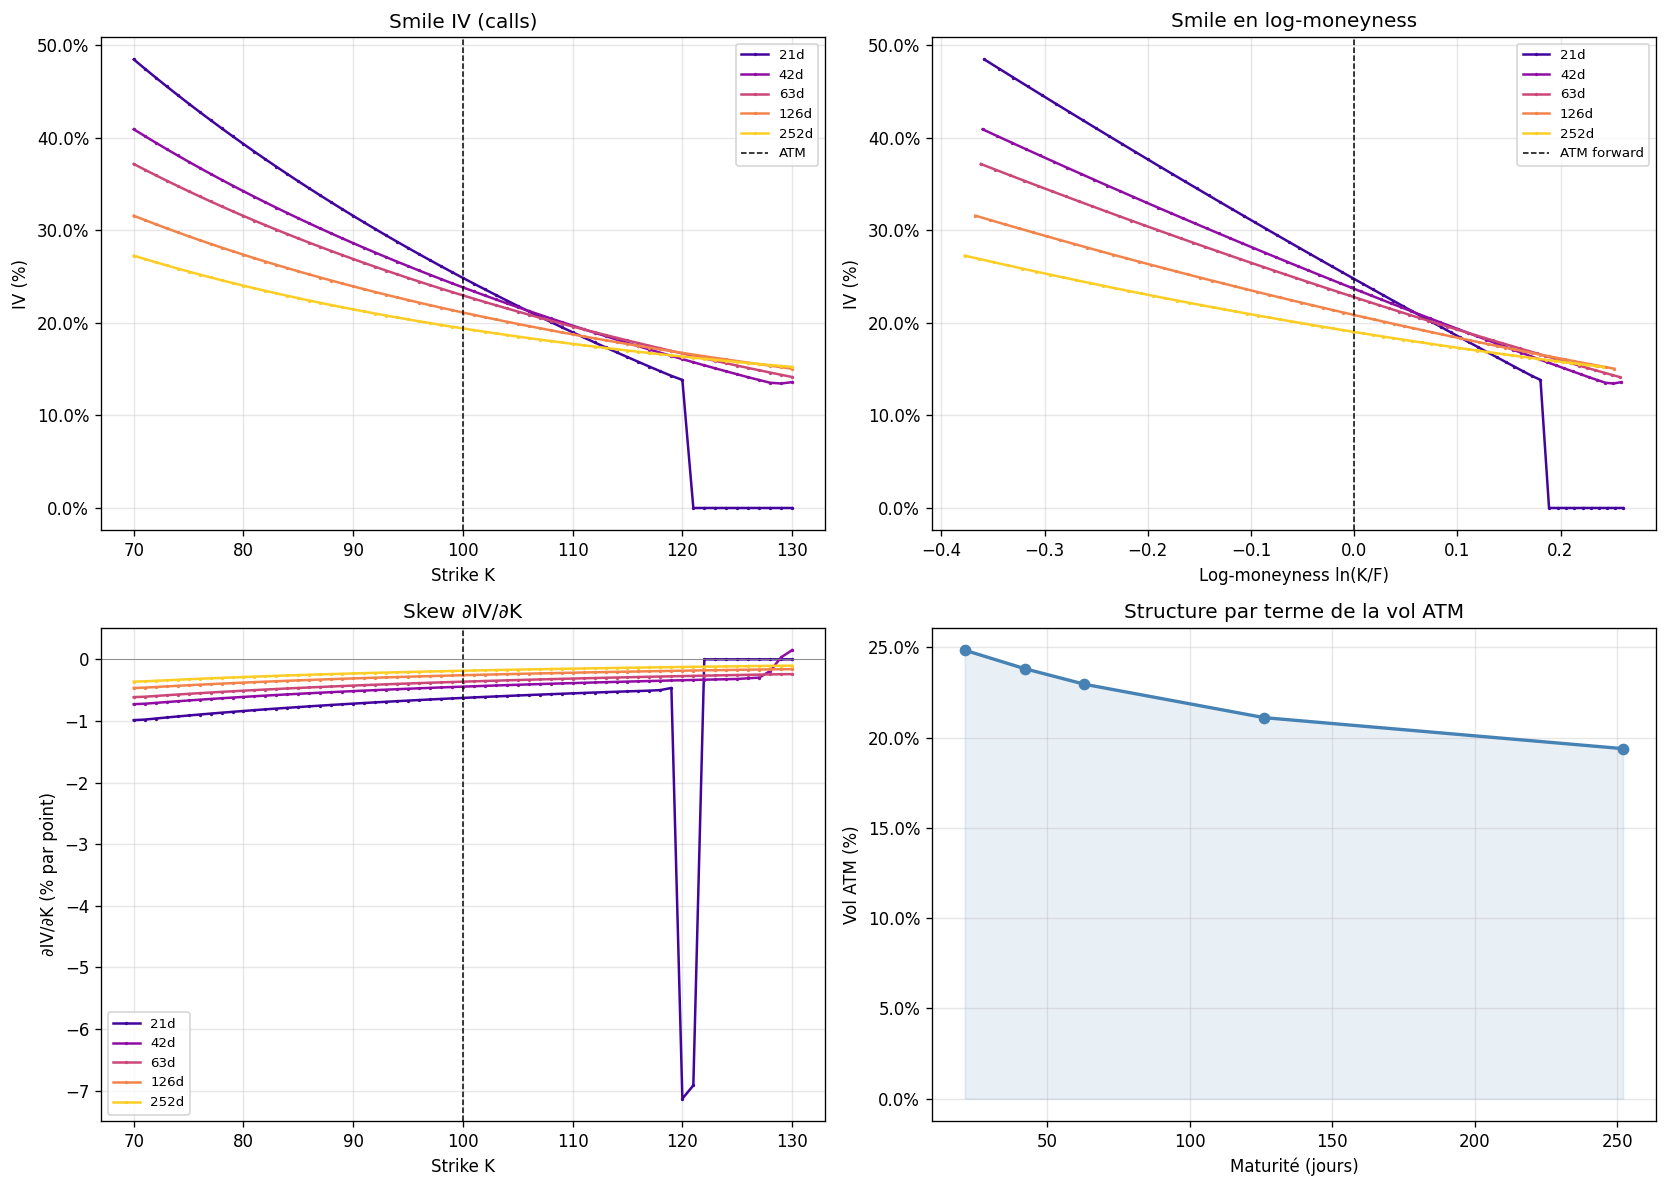

Skew ATM par maturité :


,T_years,ATM_vol_pct,skew_dK,skew_dlnK
T_days,,,,
21,0.0580,24.8400,-0.6257,-62.5730
42,0.1150,23.8200,-0.4429,-44.2910
63,0.1730,22.9500,-0.3621,-36.2110
126,0.3450,21.1100,-0.2574,-25.7390
252,0.6900,19.3900,-0.1847,-18.4680


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(MATURITIES_DAYS)))

# Smile IV vs K
ax = axes[0, 0]
for T_d, c in zip(MATURITIES_DAYS, colors):
    sub = chain[chain["T_days"] == T_d].sort_values("K")
    ax.plot(sub["K"], sub["iv_call"] * 100, color=c, marker=".", ms=2, label=f"{T_d}d")
ax.axvline(S0, color="k", ls="--", lw=0.9, label="ATM")
ax.set(xlabel="Strike K", ylabel="IV (%)", title="Smile IV (calls)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend(fontsize=8)

# Smile en log-moneyness
ax = axes[0, 1]
for T_d, c in zip(MATURITIES_DAYS, colors):
    sub = chain[chain["T_days"] == T_d].sort_values("K")
    ax.plot(sub["log_moneyness"], sub["iv_call"] * 100, color=c, marker=".", ms=2, label=f"{T_d}d")
ax.axvline(0, color="k", ls="--", lw=0.9, label="ATM forward")
ax.set(xlabel="Log-moneyness ln(K/F)", ylabel="IV (%)", title="Smile en log-moneyness")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend(fontsize=8)

# Skew dIV/dK
ax = axes[1, 0]
for T_d, c in zip(MATURITIES_DAYS, colors):
    sub   = chain[chain["T_days"] == T_d].sort_values("K")
    skew  = np.gradient(sub["iv_call"].values, sub["K"].values)
    ax.plot(sub["K"].values, skew * 100, color=c, marker=".", ms=2, label=f"{T_d}d")
ax.axvline(S0, color="k", ls="--", lw=0.9)
ax.axhline(0, color="gray", lw=0.5)
ax.set(xlabel="Strike K", ylabel="∂IV/∂K (% par point)", title="Skew ∂IV/∂K")
ax.legend(fontsize=8)

# Structure par terme de la vol ATM 
ax = axes[1, 1]
atm_iv = []
for T_d in MATURITIES_DAYS:
    sub = chain[chain["T_days"] == T_d]
    idx = (sub["K"] - S0).abs().idxmin()
    atm_iv.append(sub.loc[idx, "iv_call"] * 100)

ax.plot(MATURITIES_DAYS, atm_iv, marker="o", color="steelblue", lw=2, zorder=3)
ax.fill_between(MATURITIES_DAYS, atm_iv, alpha=0.12, color="steelblue")
ax.set(xlabel="Maturité (jours)", ylabel="Vol ATM (%)",
       title="Structure par terme de la vol ATM")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.show()

# Tableau du skew ATM par maturité 
skew_atm_rows = []
for T_d in MATURITIES_DAYS:
    sub  = chain[chain["T_days"] == T_d].sort_values("K")
    iv_v = sub["iv_call"].values
    Kv   = sub["K"].values
    Fv   = sub["forward"].values[0]
    skew_dK   = np.gradient(iv_v, Kv)
    skew_dlnK = Kv * skew_dK           # ∂IV/∂lnK = K·∂IV/∂K
    idx_atm   = np.argmin(np.abs(Kv - S0))
    atm_sigma = iv_v[idx_atm]
    skew_atm_rows.append(dict(
        T_days=T_d, T_years=round(T_d/365, 3),
        ATM_vol_pct=round(atm_sigma * 100, 2),
        skew_dK=round(skew_dK[idx_atm] * 100, 4),
        skew_dlnK=round(skew_dlnK[idx_atm] * 100, 3),
    ))
print("Skew ATM par maturité :")
display(pd.DataFrame(skew_atm_rows).set_index("T_days"))

## 8. Surface des Grecques

On visualise les grecques des calls en fonction du strike,  
pour chaque maturité disponible.

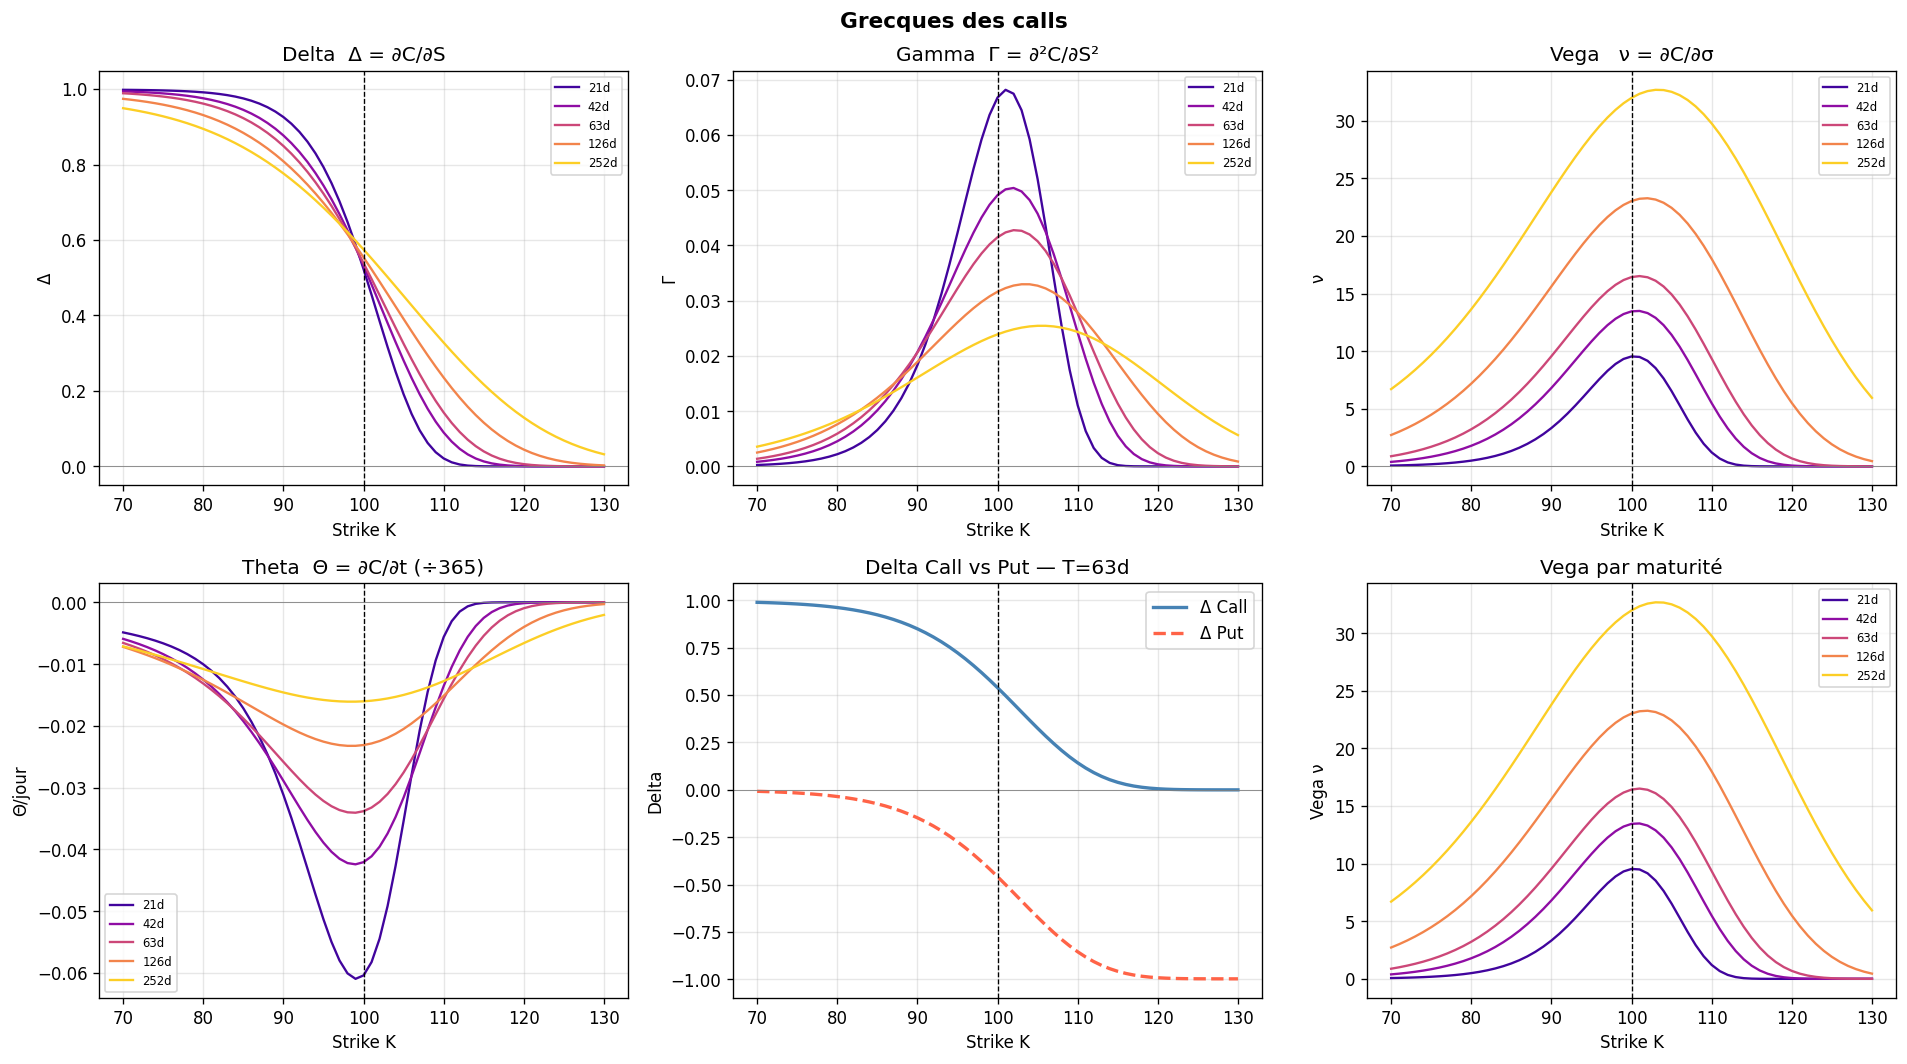

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Grecques des calls", fontsize=13, fontweight="bold")

greek_specs = [
    ("call_delta", "Delta  Δ = ∂C/∂S",       "Δ"),
    ("call_gamma", "Gamma  Γ = ∂²C/∂S²",     "Γ"),
    ("call_vega",  "Vega   ν = ∂C/∂σ",       "ν"),
    ("call_theta", "Theta  Θ = ∂C/∂t (÷365)", "Θ/jour"),
]

for i, (col, title, ylabel) in enumerate(greek_specs):
    ax = axes.flat[i]
    for T_d, c in zip(MATURITIES_DAYS, colors):
        sub = chain[chain["T_days"] == T_d].sort_values("K")
        ax.plot(sub["K"], sub[col], color=c, lw=1.4, label=f"{T_d}d")
    ax.axvline(S0, color="k", ls="--", lw=0.8)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set(xlabel="Strike K", ylabel=ylabel, title=title)
    ax.legend(fontsize=7)

# Delta call vs put (parité : Δ_put = Δ_call - e^{-qT})
ax = axes.flat[4]
T_ref = MATURITIES_DAYS[2]
sub   = chain[chain["T_days"] == T_ref].sort_values("K")
ax.plot(sub["K"], sub["call_delta"], color="steelblue", lw=2, label="Δ Call")
ax.plot(sub["K"], sub["put_delta"],  color="tomato",    lw=2, ls="--", label="Δ Put")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(S0, color="k", ls="--", lw=0.8)
ax.set(xlabel="Strike K", ylabel="Delta", title=f"Delta Call vs Put — T={T_ref}d")
ax.legend()

# Vega par maturité (surface légère)
ax = axes.flat[5]
for T_d, c in zip(MATURITIES_DAYS, colors):
    sub = chain[chain["T_days"] == T_d].sort_values("K")
    ax.plot(sub["K"], sub["call_vega"], color=c, lw=1.4, label=f"{T_d}d")
ax.axvline(S0, color="k", ls="--", lw=0.8)
ax.set(xlabel="Strike K", ylabel="Vega ν", title="Vega par maturité")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 9. Export de la chaîne

In [12]:
# Export to CSV
out_path = "option_chain.csv"
chain.round(6).to_csv(out_path, index=False)
print(f"Chain exported : {out_path}  ({len(chain)} rows, {len(chain.columns)} columns)")
print("Columns :", list(chain.columns))

Chain exported : option_chain.csv  (305 rows, 24 columns)
Columns : ['K', 'T_days', 'T', 'moneyness', 'log_moneyness', 'forward', 'vol_used', 'call_mid', 'call_bid', 'call_ask', 'put_mid', 'put_bid', 'put_ask', 'pcp_error', 'call_delta', 'call_gamma', 'call_vega', 'call_theta', 'put_delta', 'put_gamma', 'put_vega', 'put_theta', 'iv_call', 'iv_put']


Here is a link of the portfolio page:

https://portfolio-eliasbenguedda.fr/learning/data.html

## 4.2 THE VOLATILITY SURFACE

### 4.2.1 The Implied Volatility Skew

Interview questions:

What should one do if he thinks that the implied volatility (the skew) will be steeper

--> If one believes the skew to be steeper (or flatter) than it should be, one way to take this view is to sell (or buy) a put spread (this is the combination of two puts with different strikes). Since the put option has a positive sensitivity to volatility (that is, as volatility increases, its price increases) the buyer of the put is therefore buying volatility, and the seller of the put is selling volatility. Think about vega.

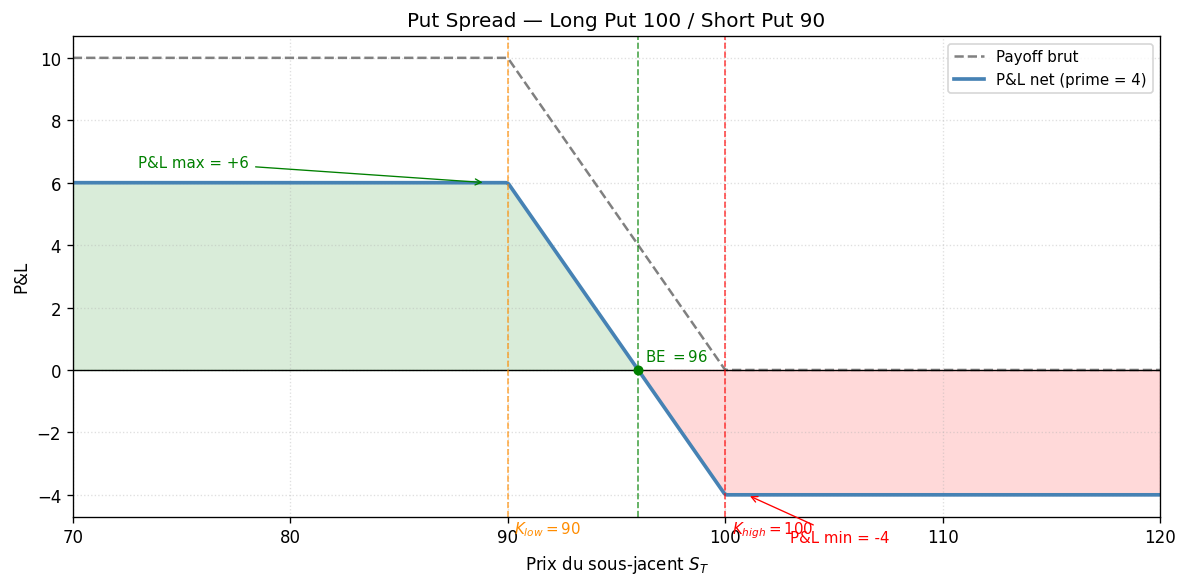

In [13]:
Image("images/put-spread.png")

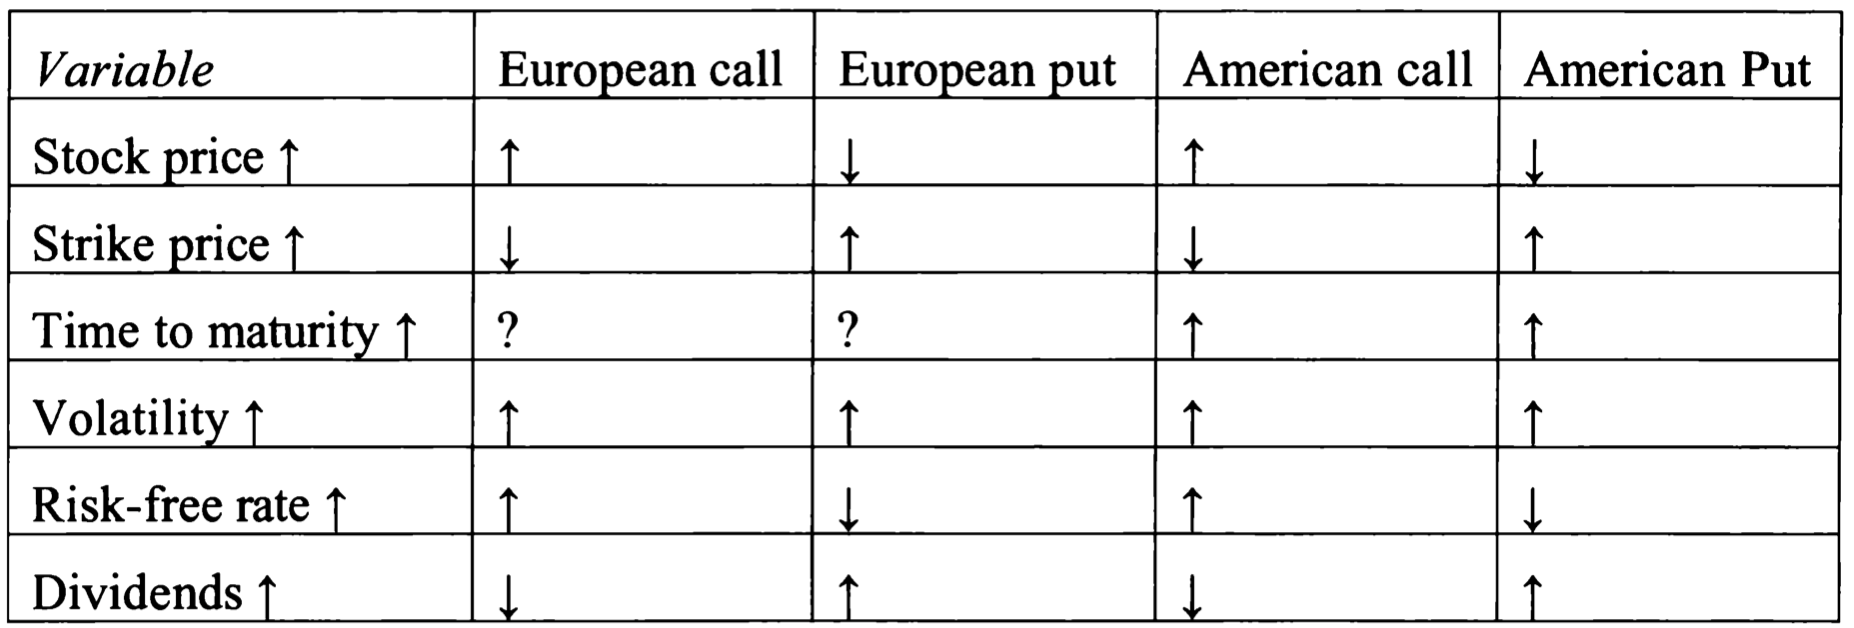

In [14]:
Image("images/impact-on-option-prices.png")

This is why if you think the skew should be steeper, the options are over priced and one should buy a put spread.

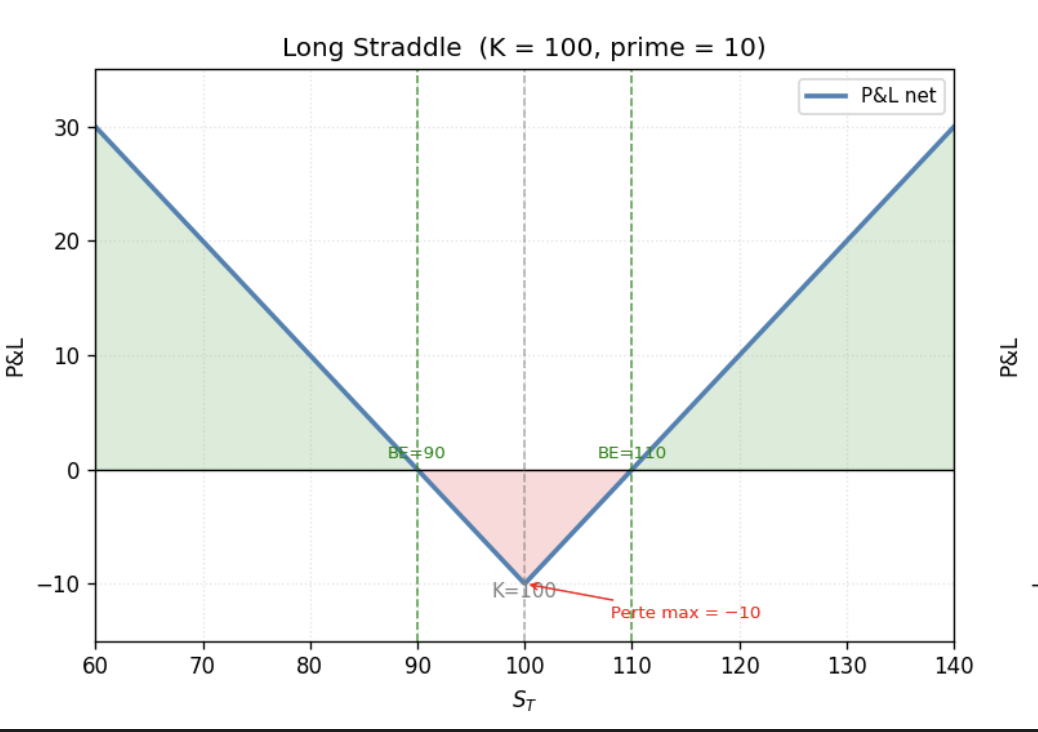

In [15]:
Image("images/long-straddle.png")

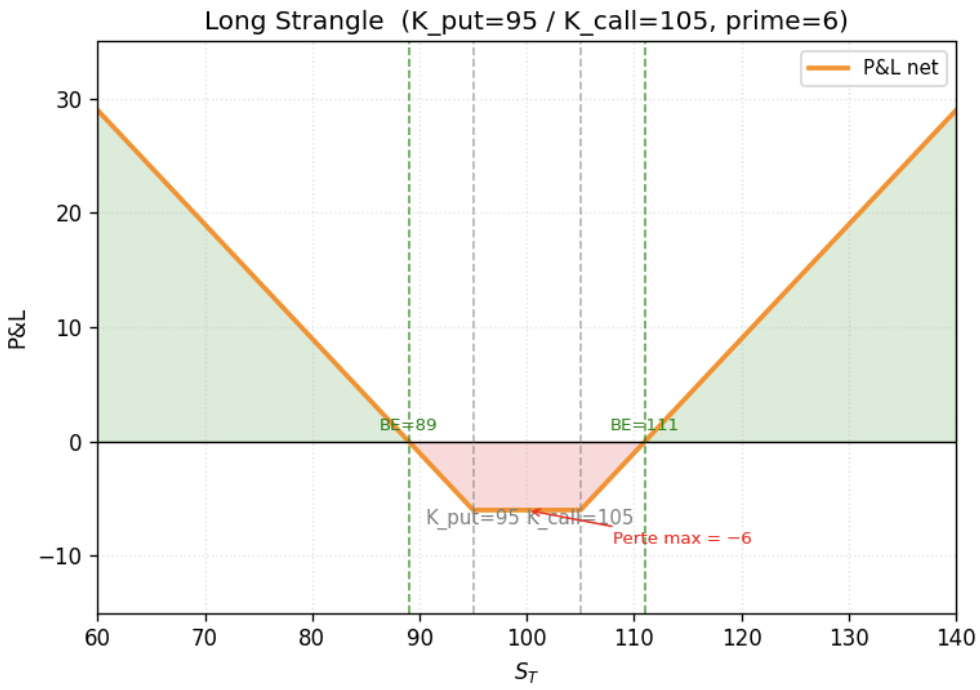

In [16]:
Image("images/long-strangle.png")

If we compare the implied volatility skews of an index and that of a stock we find that index volatilities are more skewed than those of a single stock. The reason for this is that if stocks are all dropping during a market decline, the realized correlation between them rises, and an equity index is a weighted average of different stocks.

When we talk about convexity we look at the curvature of the implied volatility curve. If one wants to trade the convexity here are the different strategies that can be done:

butterfly spread : if we go long butterfly spread then we are long a 90% and 110% strike call option meaning that we are long implied volatility. If the implied vol curve becomes more convex then it means that these two implied volatilities have increased making the butterfly spread more valuable. 

--> The holder of a butterfly sprad is therefore long implied skew convexity.

### 4.2.2 Term Structure of Volatilities

Implied volatility is in general a function of maturity: longer maturities have an higher implied volatility than short maturities. This is generally the case in calm periods when implied volatilities are low. This curve can also be decreasing when we have exceptional events such as covid, Iran war, Trump allocution.. which brings a huge incertainty about the future.

calendar spread: which is the difference of two call options of the same maturities but different maturities

If we look at the implied volatility skew for various maturities we notice that the short-term
skew is much steeper than the long-term skew, and generally flattens out as maturities increase.

## 4.3 VOLATILITY MODELS